# Macro

In [1]:
import numpy as np
import pandas as pd
from esda import Moran
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from libpysal.weights import DistanceBand
from scipy.spatial import distance_matrix

dataA1 = pd.read_csv('../ComputedData/Accident/DataA1_with_MRT_Youbike_Parkinglot.csv')
dataA2 = pd.read_csv('../ComputedData/Accident/DataA2_with_MRT_Youbike_Parkinglot.csv')
taiwan = gpd.read_file('../Data/OFiles_9e222fea-bafb-4436-9b17-10921abc6ef2/TOWN_MOI_1140318.shp')
taiwan = taiwan[(~taiwan['TOWNNAME'].isin(['旗津區', '頭城鎮'])) & 
                (~taiwan['COUNTYNAME'].isin(['金門縣', '連江縣', '澎湖縣']))]

In [2]:
from Analyze.utils import specific_polygon, plot_hex_grid, get_isa_plot, calculate_gi, plot_gi

filtered_A2 = dataA2[dataA2['當事者順位'] == 1]
# filtered_A2 = filtered_A2[filtered_A2['發生月份'] == 1]
print(filtered_A2.shape)

(317023, 54)


(93683, 62)
create hexagon
get grid


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')


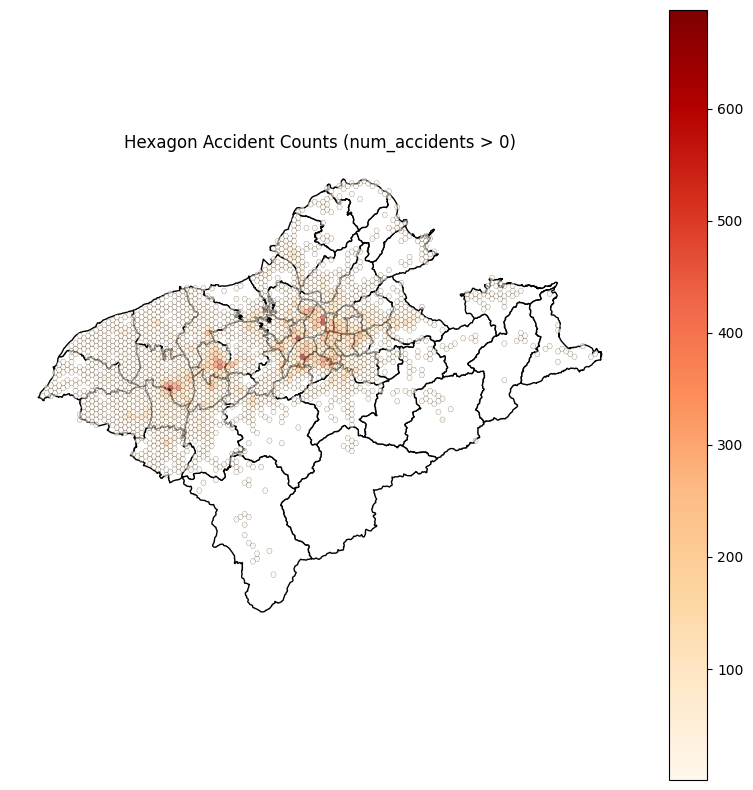

create hexagon
get grid


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')


Processing threshold: 1000 meters
nan
Processing threshold: 2000 meters
8.868761432508844
Processing threshold: 3000 meters
8.868761432508844
Processing threshold: 4000 meters
9.396507404269869
Processing threshold: 5000 meters
8.93151144347064
Processing threshold: 6000 meters


/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:219: RuntimeWarning: invalid value encountered in scalar divide
  self.VI_norm = v_num / v_den - (1.0 / (n - 1)) ** 2
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:231: RuntimeWarning: invalid value encountered in scalar divide
  VIR = (A - B) / ((n - 1) * (n - 2) * (n - 3) * s02) - EI * EI
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:238: RuntimeWarning: divide by zero encountered in scalar divide
  return self.n / self.w.s0 * inum / self.z2ss
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  return self.n / self.w.s0 * inum / self.z2ss


8.278528762303607
Processing threshold: 7000 meters
7.477206266455499
Processing threshold: 8000 meters
7.5999347803751265
Processing threshold: 9000 meters
7.543065806996773
Processing threshold: 10000 meters
6.509613419007366


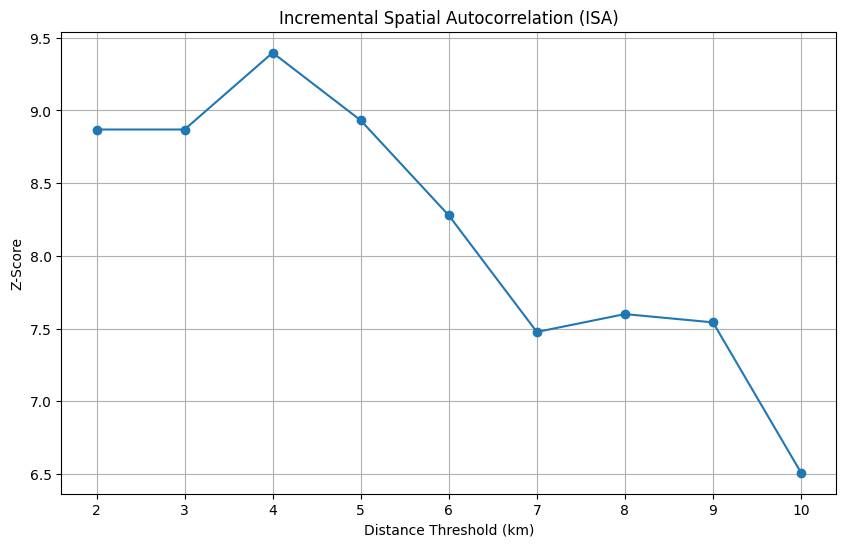

最佳分析距離 (m): 4000
Z-score: 9.3965
Moran's I: 0.2923


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:107: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.centroid


     num_accidents      GiZScore
34               2 -6.773585e-15
111              2 -6.773585e-15
112              2 -6.773585e-15
187              1 -6.773682e-15
188              2 -6.773585e-15


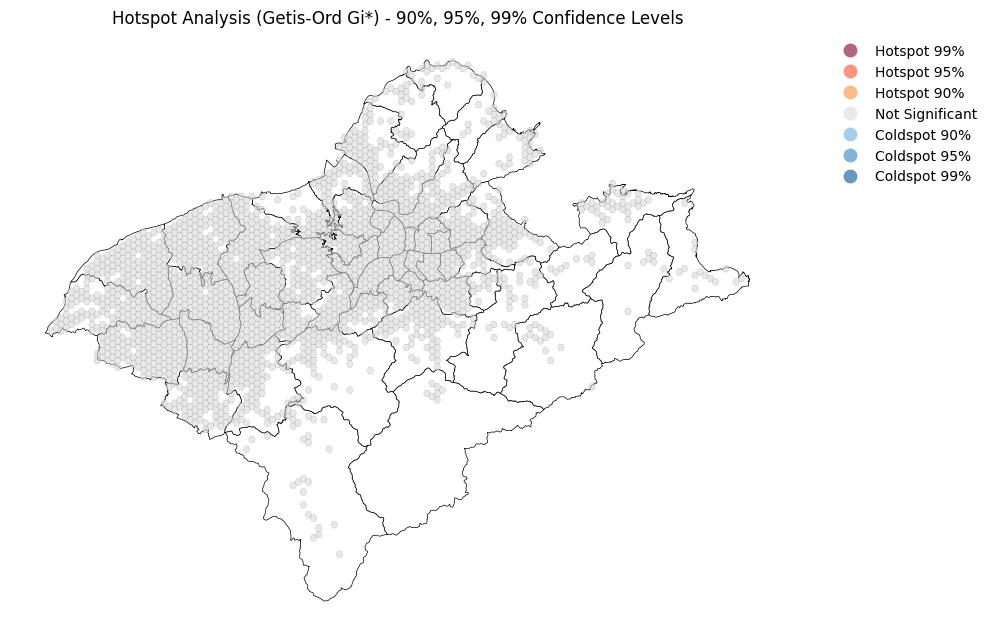

In [3]:
# 特定區域的polygon
specific_A2, taiwan_specific = specific_polygon(filtered_A2, taiwan, ['臺北市', '新北市', '桃園市'])
# 對特定區域以及grid做圖
hex_grid = plot_hex_grid(specific_A2, taiwan_specific, 100, 0.005)
# 計算ISA以及做圖
best_distance = get_isa_plot(specific_A2, 100)
# 依照最佳距離計算gi
grid = calculate_gi(best_distance, hex_grid)
plot_gi(taiwan_specific, grid)

(77297, 62)
create hexagon
get grid


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')


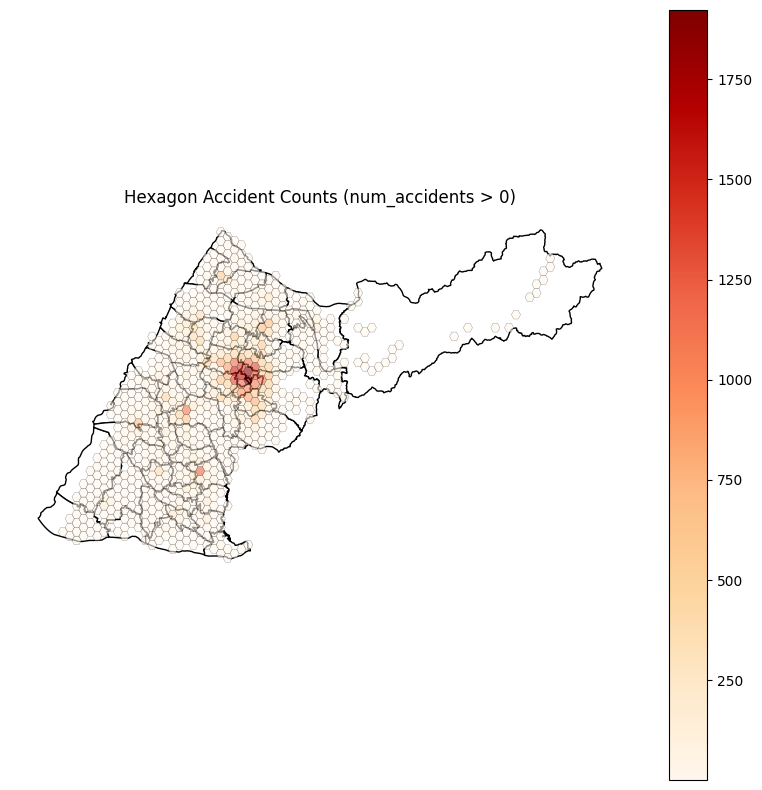

create hexagon
get grid


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')


Processing threshold: 1000 meters
nan
Processing threshold: 2000 meters
17.713585586012364
Processing threshold: 3000 meters
17.713585586012364
Processing threshold: 4000 meters


/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:219: RuntimeWarning: invalid value encountered in scalar divide
  self.VI_norm = v_num / v_den - (1.0 / (n - 1)) ** 2
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:231: RuntimeWarning: invalid value encountered in scalar divide
  VIR = (A - B) / ((n - 1) * (n - 2) * (n - 3) * s02) - EI * EI
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:238: RuntimeWarning: divide by zero encountered in scalar divide
  return self.n / self.w.s0 * inum / self.z2ss
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  return self.n / self.w.s0 * inum / self.z2ss


22.649510169062985
Processing threshold: 5000 meters
23.706782742001476
Processing threshold: 6000 meters
24.53277425328625
Processing threshold: 7000 meters
23.771561664269356
Processing threshold: 8000 meters
23.61205484648624
Processing threshold: 9000 meters
23.57281491439197
Processing threshold: 10000 meters
23.023858353495033


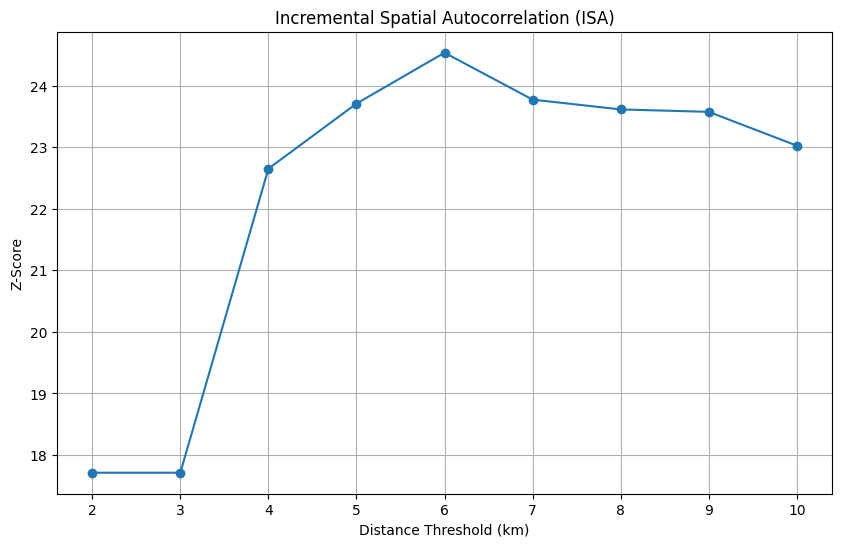

最佳分析距離 (m): 6000
Z-score: 24.5328
Moran's I: 0.4550


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:107: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.centroid


    num_accidents      GiZScore
3               3 -1.023981e-15
41              2 -1.023997e-15
42              7 -1.023919e-15
43              6 -1.023934e-15
79              1 -1.024013e-15


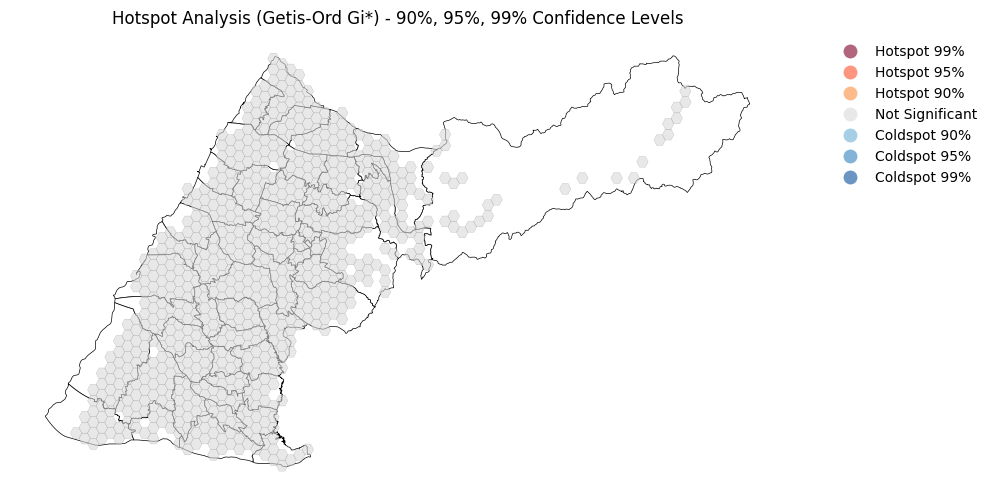

In [9]:
specific_A2, taiwan_specific = specific_polygon(filtered_A2, taiwan, ['臺中市', '彰化縣'])
hex_grid = plot_hex_grid(specific_A2, taiwan_specific, 30, 0.01)
best_distance = get_isa_plot(specific_A2, 30)
grid = calculate_gi(best_distance, hex_grid)
plot_gi(taiwan_specific, grid)

(28441, 62)
create hexagon
get grid


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')


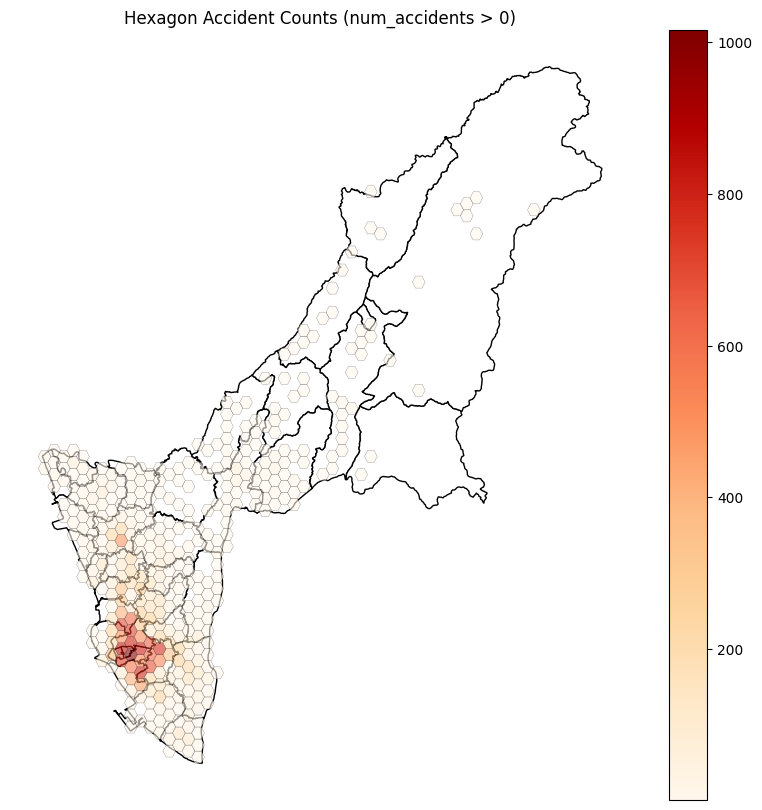

create hexagon
get grid
Processing threshold: 1000 meters
nan
Processing threshold: 2000 meters
10.643016246201636
Processing threshold: 3000 meters


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:71: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997" ...
Right CRS: EPSG:4326

  joined = gpd.sjoin(gdf, hex_grid, how='left', predicate='within')
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:219: RuntimeWarning: invalid value encountered in scalar divide
  self.VI_norm = v_num / v_den - (1.0 / (n - 1)) ** 2
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:231: RuntimeWarning: invalid value encountered in scalar divide
  VIR = (A - B) / ((n - 1) * (n - 2) * (n - 3) * s02) - EI * EI
/Users/wangqiqian/opt/anaconda3/envs/ST-RTA/lib/python3.9/site-packages/esda/moran.py:238: RuntimeWarning: divide by zero encountered in scalar divide
  return self.n / self.w.s0 * inum / self.z

10.643016246201636
Processing threshold: 4000 meters
13.798403682654882
Processing threshold: 5000 meters
13.859144736779177
Processing threshold: 6000 meters
14.167839152492972
Processing threshold: 7000 meters
14.799796601204061
Processing threshold: 8000 meters
14.180510729505293
Processing threshold: 9000 meters
12.823311363655366
Processing threshold: 10000 meters
11.313857618603087


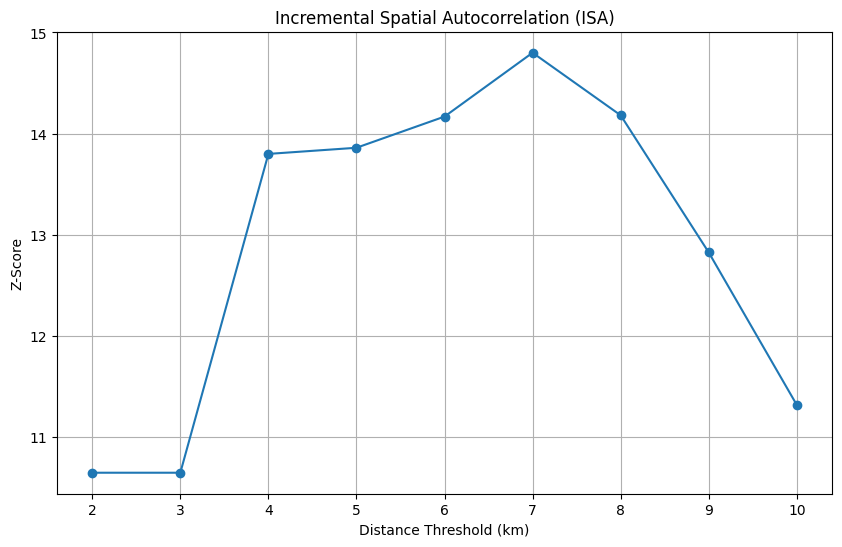

最佳分析距離 (m): 7000
Z-score: 14.7998
Moran's I: 0.3723


/Users/wangqiqian/Desktop/ST-RTA/Test/utils.py:107: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.centroid


    num_accidents      GiZScore
24             14 -2.437540e-15
25             12 -2.359104e-15
70             11 -2.359202e-15
71             17 -2.358619e-15
72             15 -2.358812e-15


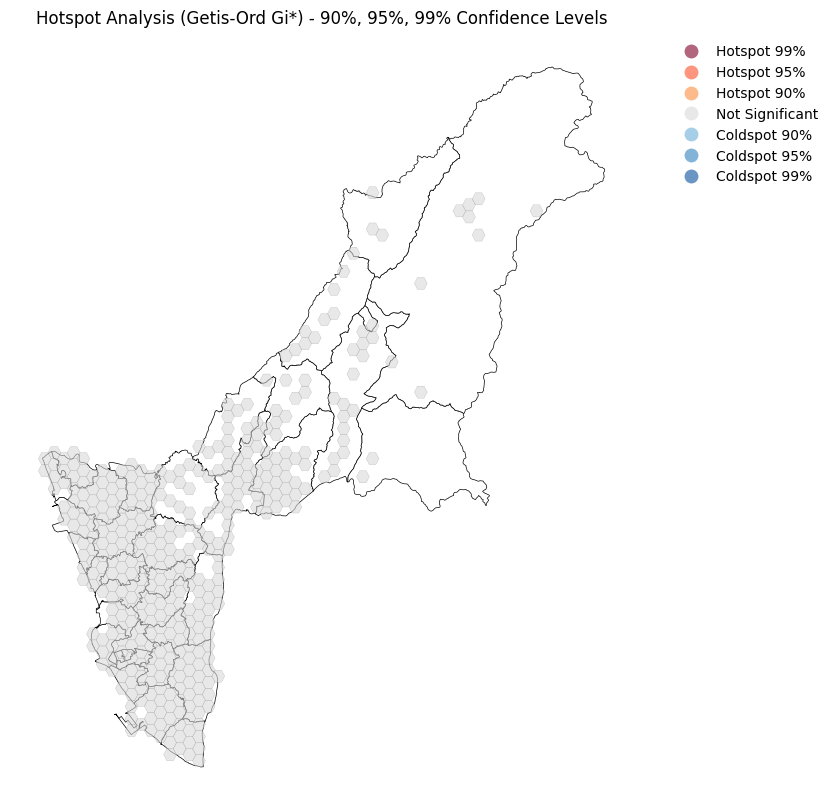

In [10]:
specific_A2, taiwan_specific = specific_polygon(filtered_A2, taiwan, ['高雄市'])
hex_grid = plot_hex_grid(specific_A2, taiwan_specific, 30, 0.01)
best_distance = get_isa_plot(specific_A2, 30)
grid = calculate_gi(best_distance, hex_grid)
plot_gi(taiwan_specific, grid)